Epoch 1/10
15/15 [==============================] - 1s 1ms/step - loss: 0.5168 - accuracy: 0.8110
Epoch 2/10
15/15 [==============================] - 0s 1ms/step - loss: 0.2536 - accuracy: 0.9451
Epoch 3/10
15/15 [==============================] - 0s 1ms/step - loss: 0.1540 - accuracy: 0.9582
Epoch 4/10
15/15 [==============================] - 0s 1ms/step - loss: 0.1146 - accuracy: 0.9648
Epoch 5/10
15/15 [==============================] - 0s 1ms/step - loss: 0.0927 - accuracy: 0.9736
Epoch 6/10
15/15 [==============================] - 0s 2ms/step - loss: 0.0773 - accuracy: 0.9824
Epoch 7/10
15/15 [==============================] - 0s 1ms/step - loss: 0.0671 - accuracy: 0.9868
Epoch 8/10
15/15 [==============================] - 0s 1ms/step - loss: 0.0610 - accuracy: 0.9890
Epoch 9/10
15/15 [==============================] - 0s 1ms/step - loss: 0.0549 - accuracy: 0.9890
Epoch 10/10
4/4 [==============================] - 0s 1ms/step


Text(0.5, 1.0, 'Neural Network Confusion Matrix')

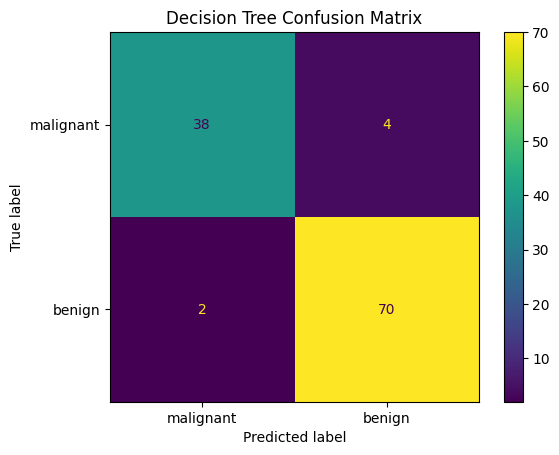

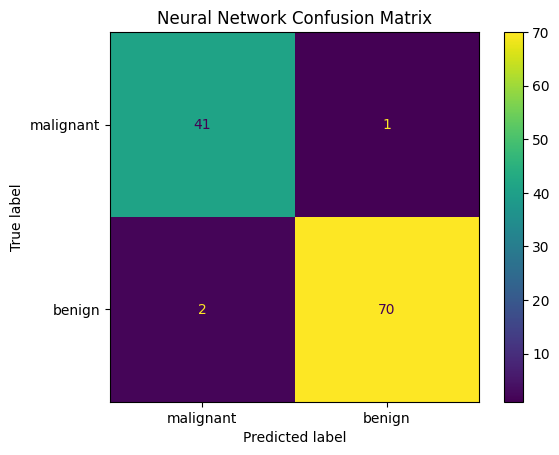

In [4]:
# imports
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# loading the dataset into breast_cancer_dataset
breast_cancer_dataset = load_breast_cancer()

# setting the random set so that we can reproduce the same results
tf.random.set_seed(42)

# creating my scaler so that I can standardize the features
scaler = StandardScaler()

# setting my features to equal X and target to label y
X = breast_cancer_dataset.data
y = breast_cancer_dataset.target

# creating my train and test split with the test size being 20%
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

# scaling the training and testing data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# creating the model based with a criterion of entropy and having a max_depth of 3 to combat overfitting
decision_tree_classifier_model = DecisionTreeClassifier(criterion = 'entropy', random_state = 42, max_depth=3)

# training the decision tree model
decision_tree_classifier_model.fit(x_train, y_train)

# creating the sequential neural network model.
# It has 3 layers, 2 hidden and one input layer expecting 30 features
# Then the output layer is binary classification which is why it only has one neuron
neural_network_model = Sequential(
    layers=[
        Dense(64, activation='relu', input_shape=(30,)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid'),
    ]
)

# compiling the neural network
# binary_crossentropy is used for binary classification
# the neural network metric is accuracy
# the optimizer is adam for efficiency
neural_network_model.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer='adam')

# training the neural network model
neural_network_model.fit(x_train_scaled, y_train, epochs=10)


# CONFUSION MATRICES

# making predictions using the trained decision tree classifier on the testing data
y_pred_decision_tree = decision_tree_classifier_model.predict(x_test)

# creating the confusion matrix for the decision tree
cm_decision_tree = confusion_matrix(y_test, y_pred_decision_tree)

# creating the visualization for the decision tree
display_decision_tree = ConfusionMatrixDisplay(confusion_matrix=cm_decision_tree, display_labels=breast_cancer_dataset.target_names)
display_decision_tree.plot()
# creating a descriptive title for the confusion matrix for the decision tree
display_decision_tree.ax_.set_title("Decision Tree Confusion Matrix")


# making predictions using the trained neural network on the testing data
y_pred_neural_network_prob = neural_network_model.predict(x_test_scaled)

# this ouputs probabilites from 0-1 so we need to make it a binary number either 1 or 0 no inbetween
y_pred_neural_network = (y_pred_neural_network_prob > 0.5).astype(int).flatten()

# creating the visualization for the neural network
cm_neural_network = confusion_matrix(y_test, y_pred_neural_network)
disp_neural_network = ConfusionMatrixDisplay(confusion_matrix=cm_neural_network, display_labels=breast_cancer_dataset.target_names)
disp_neural_network.plot()
# creating a descriptive title for the confusion matrix for the neural network
disp_neural_network.ax_.set_title("Neural Network Confusion Matrix")

# Answers
# I would prefer the neural network for this task because it had less false negatives. In the medical world and having to predict a serious medical condition such as cancer it is crucial that you can correctly identify the malignant cases. Therefore, because the neural network only missed one false negative, I would prefer it to predict breast cancer.

# Decision Tree: One advantage of the decision tree is that is a white box machine learning model, meaning that it is much easier to trace through and understand why the model made the certain predictions it did. For example, with the decision tree you can trace exactly which features like worst radius and worst concave points led to a malignant prediction. However, one limitation of the decision tree is its tendency to overfit on data. Especially on this dataset it is very easy for the model to overfit and learn based off of the individual training points instead of finding patterns within the data. Therefore, we have to constrain it which can then limit its capability and end up not being as accurate.

# Neural Network: An advantage that a neural network has in this context is that it can learn much easily learn non-linear complex relations within the features instead of a simple true or false splitting at the nodes. This allows it to correctly identify difficult cases where the decision tree missed. A limitation of the neural network is that it is a black box. We can't see the specific reason as to why it labeled a certain case as malignant versus benign, meaning that its impossible to trace through the neural network and interpret the model.


